## California Housing Dataset

- EDA
- Multiple Linear Regression(deg=1)
- Polynomial regression (deg=2)
- Polynomial Regression degree using GridSearch
- Random Forest Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [2]:
housing = fetch_california_housing()

In [3]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
housing.target_names

['MedHouseVal']

In [5]:
df = pd.DataFrame(housing["data"], columns = housing["feature_names"])
df["MedHouseVal"] =housing["target"]
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [8]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [9]:
df.corr()["MedHouseVal"].sort_values(ascending =False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

In [10]:
df[df.duplicated()]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal


In [11]:
df.duplicated().sum()

np.int64(0)

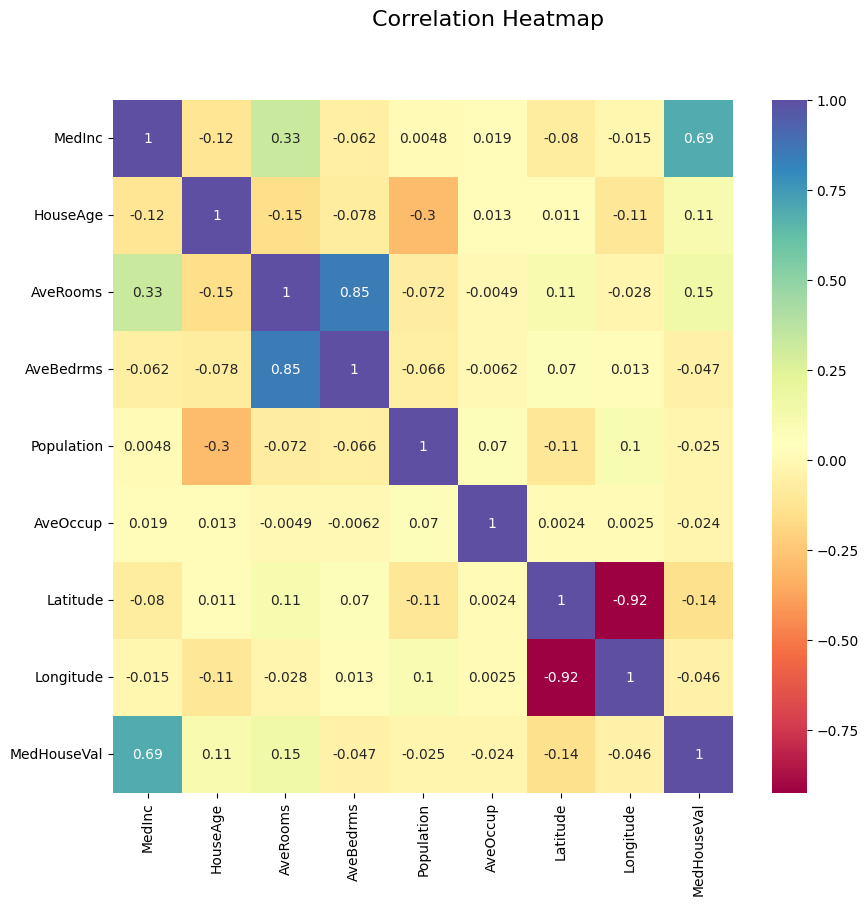

In [12]:
plt.figure(figsize=(10,9))
sns.heatmap(df.corr(),annot =True, cmap = "Spectral")
plt.suptitle("Correlation Heatmap", fontsize =16);

In [13]:
df.corr()["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

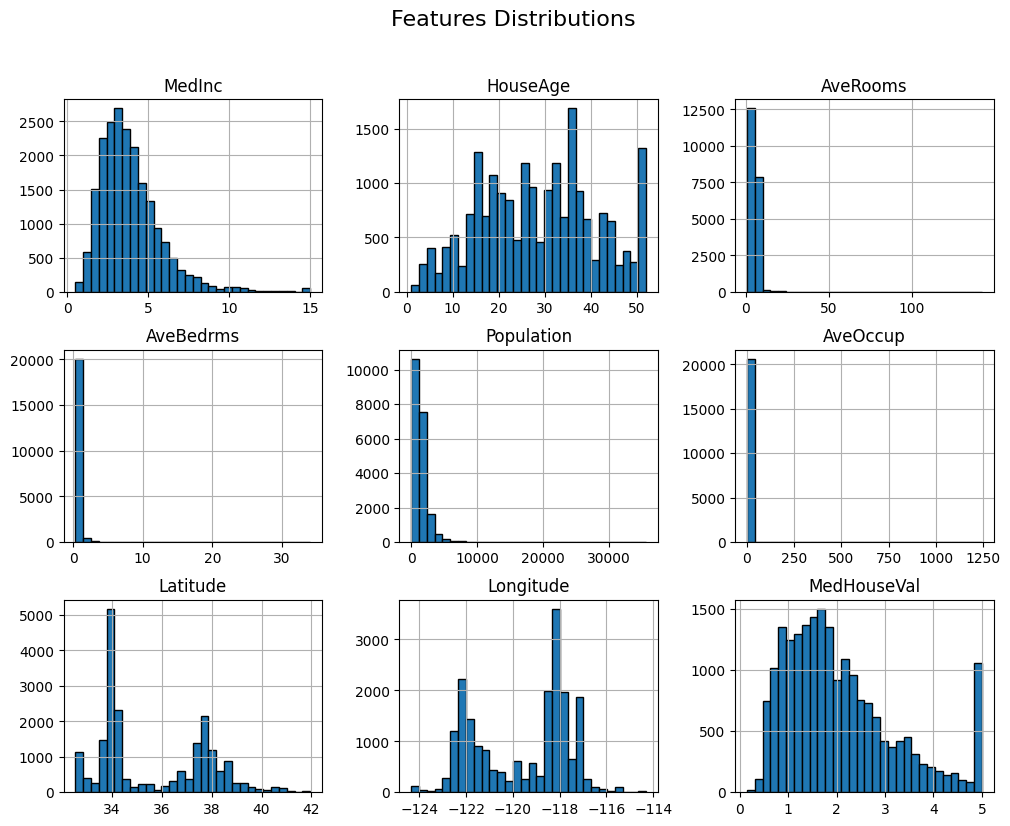

In [14]:
df.hist(bins=30, figsize=(12,9), edgecolor ="black")
plt.suptitle("Features Distributions", fontsize =16);

#### Outlier Detection

In [15]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {outliers} outliers detected")

MedInc: 681 outliers detected
HouseAge: 0 outliers detected
AveRooms: 511 outliers detected
AveBedrms: 1424 outliers detected
Population: 1196 outliers detected
AveOccup: 711 outliers detected
Latitude: 0 outliers detected
Longitude: 0 outliers detected
MedHouseVal: 1071 outliers detected


#### Multiple Linear Regression
House Price = β0 + β1*MedInc + β2*HouseAge + β3*AveRooms + ... + error

In [16]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

In [18]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [19]:
print("df Shape                    :", df.shape) 
print("X Shape, y Shape            :", X.shape, y.shape)
print("X_train Shape, y_train Shape:", X_train.shape, y_train.shape)
print("X_test Shape, y_test Shape  :", X_test.shape, y_test.shape)

df Shape                    : (20640, 9)
X Shape, y Shape            : (20640, 8) (20640,)
X_train Shape, y_train Shape: (16512, 8) (16512,)
X_test Shape, y_test Shape  : (4128, 8) (4128,)


In [20]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_pipe.fit (X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print("=== Linear Regression ===")
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Test R²   :", r2_score(y_test, y_pred_lr))

=== Linear Regression ===
Test RMSE : 0.7380227636627962
Test R²   : 0.5970946680312594


#### Polynomial Regression (deg =2)

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # generate polynomial terms
    ('scaler', StandardScaler()),                               # scale them
    ('model', LinearRegression())
])

poly_pipe.fit(X_train, y_train)
y_pred_poly = poly_pipe.predict(X_test)

print("=== Polynomial Regression ===")
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
print("Test R²   :", r2_score(y_test, y_pred_poly))

=== Polynomial Regression ===
Test RMSE : 0.7077335154156326
Test R²   : 0.6294873630199603


In [22]:
## Polynomial Regression (deg=2) vs Linear Regression(deg =1)
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# Define RMSE scorer (since sklearn only has MSE by default)
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Cross-validation for Linear Regression pipeline
scores_lr = cross_val_score(lr_pipe, X_train, y_train,cv=5, scoring=rmse_scorer)
rmse_lr = np.sqrt(-scores_lr)
print("Linear Regression CV RMSE per fold:", rmse_lr)
print("Linear Regression Mean CV RMSE:", rmse_lr.mean())

# Cross-validation for Polynomial Regression pipeline
scores_poly = cross_val_score(poly_pipe, X_train, y_train,cv=5, scoring=rmse_scorer)
print("="*5)   
rmse_poly = np.sqrt(-scores_poly)
print("Polynomial Regression CV RMSE per fold:", rmse_poly)
print("Polynomial Regression Mean CV RMSE:", rmse_poly.mean())

Linear Regression CV RMSE per fold: [3.70002231 0.71035364 0.72650214 0.71896039 0.73216958]
Linear Regression Mean CV RMSE: 1.3176016133143953
=====
Polynomial Regression CV RMSE per fold: [175.23087381   0.63304964   0.7286499    0.65050263   0.66554461]
Polynomial Regression Mean CV RMSE: 35.58172411959242


Polynomial reg. shows large error (**175 RMSE**) in one of the folds ( does worse than Linear Regr. deg=1)

In [23]:
## Find best Degree of Polynomial
from sklearn.model_selection import GridSearchCV
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Grid search over polynomial degrees
param_grid = {'poly__degree': [1, 2, 3, 4]}  # degrees to test
grid = GridSearchCV(poly_pipe, param_grid,
                    cv=5,
                    scoring='neg_root_mean_squared_error',
                    n_jobs=-1)

grid.fit(X_train, y_train)
results = grid.cv_results_

# Best degree
print("Best polynomial degree:", grid.best_params_['poly__degree'])

# Evaluate on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R²  :", r2_score(y_test, y_pred))

# Check Results
pd.options.display.float_format = '{:.6f}'.format
df_results=pd.DataFrame(results)
df_results[['param_poly__degree','mean_test_score','std_test_score','rank_test_score']]


Best polynomial degree: 1
Test RMSE: 0.7380227636627962
Test R²  : 0.5970946680312594


,param_poly__degree,mean_test_score,std_test_score,rank_test_score
0,1,-1.317602,1.191233,1
1,2,-35.581724,69.824582,2
2,3,-6880.247556,13758.537094,3
3,4,-4477314.582054,8954453.263332,4


#### mean_test_score:
- average cross-validation score across all folds
- scoring='neg_root_mean_squared_error' negative RMSE is shown (flip sign for RMSE)
#### std_test_score
-  standard deviation of the CV scores across fold (variation)
-  lesser the number more stable across folds

### Random Forest Regressor

- ensemble method (team of models) based on Decision Trees
- creates a “forest” of many trees and averages their prediction
- uses bootstrap aggregation(bagging), random feature selection and prediction is average of all tree outputs.
- captures non-linear relationships and feature relationships.


In [24]:
from sklearn.ensemble import RandomForestRegressor
# Pipeline for Random Forest
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),      # Scaling is optional for trees but harmless
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)

print("=== Random Forest Regressor ===")
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Test R²   :", r2_score(y_test, y_pred_rf))

=== Random Forest Regressor ===
Test RMSE : 0.5215664677077302
Test R²   : 0.7987745884814985


In [25]:
lr_param_grid = {
    'model__fit_intercept': [True, False]
}

lr_grid = GridSearchCV(lr_pipe, lr_param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print("Linear Regression (LR)")
print("Best LR params:", lr_grid.best_params_)
print("Best LR CV RMSE:", -lr_grid.best_score_)
print("=*10")

      
# For Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, 
                       scoring='neg_root_mean_squared_error', 
                       n_jobs=-1, verbose=1)

rf_grid.fit(X_train, y_train)
print("RandomForest (RF) Regressor")
print("Best RF params:", rf_grid.best_params_)
print("Best CV RMSE:", -rf_grid.best_score_)

Linear Regression (LR)
Best LR params: {'model__fit_intercept': True}
Best LR CV RMSE: 1.3176016133143953
=*10
Fitting 5 folds for each of 12 candidates, totalling 60 fits
RandomForest (RF) Regressor
Best RF params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: 0.5079687221025724


### Intuition & Workflow 

- Start with Linear Regression
- Check for non linear relationships with Polynomial regression using GridSearchCV
- If polynomial features are unstable move to Randomforest to improve prediction accuracy.

